In [ ]:
# Step 1: Import Required Libraries

In [12]:
import pandas as pd # loading data
import numpy as np # mathematical calculations
import re # regular expressions for cleaning the data
import nltk # for basic
import matplotlib.pyplot as plt # visualization
from nltk.corpus import stopwords # to remove be verbs unwanted words
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer # for sentiment analysis
from collections import Counter
from wordcloud import WordCloud



# Download required NLTK files
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
# Step 2: Create Sample Customer Reviews

In [29]:
data = {
    "Review": [
        "The movie was absolutely amazing with brilliant acting and an engaging storyline.",
        "The storyline was weak and the acting was disappointing throughout the film.",
        "The movie was average with a few good moments but nothing extraordinary.",
        "I loved every minute of the film. The music and performances were outstanding.",
        "The visual effects were poor and the direction lacked creativity.",
        "The acting was decent, but the storyline could have been better.",
        "One of the best movies I have watched this year. It exceeded my expectations.",
        "The movie failed to keep my attention because it was slow and predictable.",
        "It was a one-time watch with a balanced mix of entertaining and dull scenes.",
        "Fantastic performances by the entire cast made the movie unforgettable."
    ]
}


# Create DataFrame
df = pd.DataFrame(data)

# Display first few rows
print("Movie Reviews Dataset:")
print(df.head())



Movie Reviews Dataset:
                                              Review
0  The movie was absolutely amazing with brillian...
1  The storyline was weak and the acting was disa...
2  The movie was average with a few good moments ...
3  I loved every minute of the film. The music an...
4  The visual effects were poor and the direction...


In [ ]:
# Step 3: Data Cleaning and  Preprocessing

In [16]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

       # convert to lowercase
       text = text.lower()
       print('lower case', text)

       # remove special characters and numbers
       text=re.sub(r'[^a-zA-Z\s]', '', text)
       print('special character', text)

       #Tokenization
       words= word_tokenize(text)
       print('tokenization', words)

       # Remove stopwords
       words = [word for word in words if word not in stop_words]
       print('stopwords', words)

       # Join words again
       cleaned_text = ' '.join(words)
       return cleaned_text

# Apply cleaning function
df['Cleaned_Review'] = df['Review'].apply(clean_text)

# Display cleaned reviews
print("\nCleaned Reviews:")
print(df[['Review', 'Cleaned_Review']])




lower case the movie was absolutely amazing with brilliant acting and an engaging storyline.
special character the movie was absolutely amazing with brilliant acting and an engaging storyline
tokenization ['the', 'movie', 'was', 'absolutely', 'amazing', 'with', 'brilliant', 'acting', 'and', 'an', 'engaging', 'storyline']
stopwords ['movie', 'absolutely', 'amazing', 'brilliant', 'acting', 'engaging', 'storyline']
lower case the storyline was weak and the acting was disappointing throughout the film.
special character the storyline was weak and the acting was disappointing throughout the film
tokenization ['the', 'storyline', 'was', 'weak', 'and', 'the', 'acting', 'was', 'disappointing', 'throughout', 'the', 'film']
stopwords ['storyline', 'weak', 'acting', 'disappointing', 'throughout', 'film']
lower case the movie was average with a few good moments but nothing extraordinary.
special character the movie was average with a few good moments but nothing extraordinary
tokenization ['the', 

In [ ]:
# Step 4: Sentiment Analysis

In [17]:
sia=SentimentIntensityAnalyzer()

def analyze_sentiment(review):
    score = sia.polarity_scores(review)

    compound = score['compound']

    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment Analysis
df['sentiment'] = df['Cleaned_Review'].apply(analyze_sentiment)

# Display sentiment analysis results
print("\nSentiment Analysis Results:")
print(df[['Review', 'sentiment']])


Sentiment Analysis Results:
                                              Review sentiment
0  The movie was absolutely amazing with brillian...  Positive
1  The storyline was weak and the acting was disa...  Negative
2  The movie was average with a few good moments ...  Positive
3  I loved every minute of the film. The music an...  Positive
4  The visual effects were poor and the direction...  Negative
5  The acting was decent, but the storyline could...  Positive
6  One of the best movies I have watched this yea...  Positive
7  The movie failed to keep my attention because ...  Negative
8  It was a one-time watch with a balanced mix of...  Positive
9  Fantastic performances by the entire cast made...  Positive


In [20]:
#Audience Opinion Summary

In [21]:
# Count each sentiment
sentiment_counts = df["sentiment"].value_counts()

print("Audience Opinion Summary")
print(sentiment_counts)

total_reviews = len(df)

positive = sentiment_counts.get("Positive", 0)
negative = sentiment_counts.get("Negative", 0)
neutral = sentiment_counts.get("Neutral", 0)

print("\nAnalysis:")

print(f"Total Reviews : {total_reviews}")
print(f"Positive Reviews : {positive}")
print(f"Negative Reviews : {negative}")
print(f"Neutral Reviews : {neutral}")

if positive > negative and positive > neutral:
    print("\nOverall Audience Opinion: The audience liked the movie.")
elif negative > positive and negative > neutral:
    print("\nOverall Audience Opinion: The audience disliked the movie.")
else:
    print("\nOverall Audience Opinion: The audience had mixed opinions.")

Audience Opinion Summary
sentiment
Positive    7
Negative    3
Name: count, dtype: int64

Analysis:
Total Reviews : 10
Positive Reviews : 7
Negative Reviews : 3
Neutral Reviews : 0

Overall Audience Opinion: The audience liked the movie.


In [ ]:
# step 5: Find Common Keywords

In [22]:
all_words =" ".join(df['Cleaned_Review'])
word_list = all_words.split()

# Count word frequency
word_freq= Counter(word_list)

# Display top 10 keywords
print("\nTop 10 Keywords:")
print(word_freq.most_common(10))



Top 10 Keywords:
[('movie', 4), ('acting', 3), ('storyline', 3), ('film', 2), ('performances', 2), ('absolutely', 1), ('amazing', 1), ('brilliant', 1), ('engaging', 1), ('weak', 1)]


In [ ]:
# Step 6: Identify Common Complaints

In [23]:
negative_reviews = df[df['sentiment'] == 'Negative']
negative_words = " ".join(negative_reviews['Cleaned_Review'])
negative_word_list = negative_words.split()
complaint_freq = Counter(negative_word_list)

# Display top 10 common complaints
print("\nTop 10 Common Complaints:")
print(complaint_freq.most_common(10))



Top 10 Common Complaints:
[('storyline', 1), ('weak', 1), ('acting', 1), ('disappointing', 1), ('throughout', 1), ('film', 1), ('visual', 1), ('effects', 1), ('poor', 1), ('direction', 1)]


In [ ]:
# Step 7:Visualization - Sentiment Count

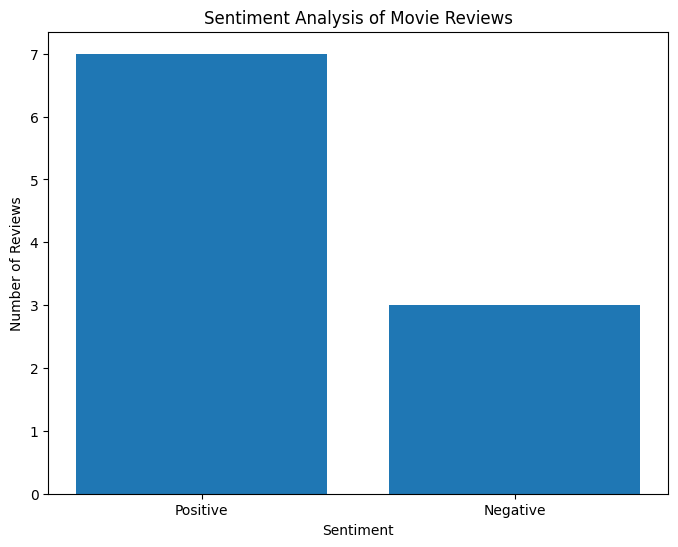

In [28]:
sentiment_counts = df['sentiment'].value_counts() # it will give category count

# Create a bar chart
plt.figure(figsize=(8, 6))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title('Sentiment Analysis of Movie Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

In [ ]:
# Step 8: Generate Word Cloud

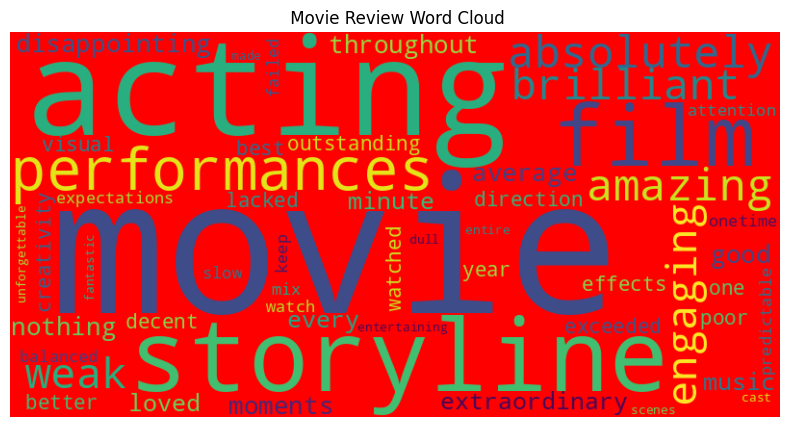

In [27]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='red'
    ).generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title(' Movie Review Word Cloud')
plt.show()